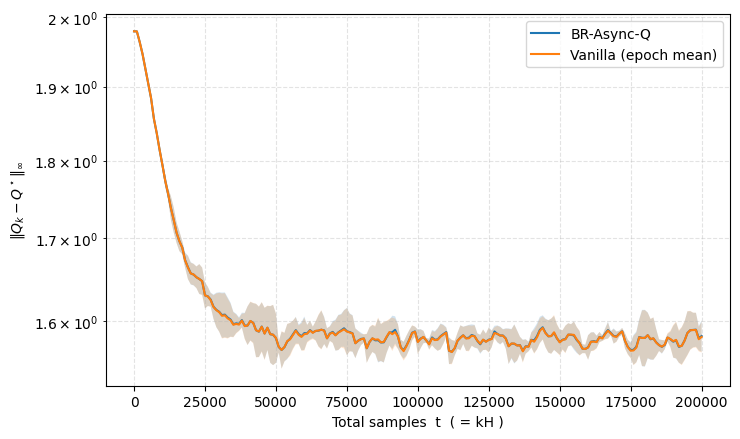

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List, Sequence, Tuple, Iterator, Optional, Union

# ============================================================
# 1) Random MDP + Value Iteration to compute Q*
# ============================================================

def mdpgen(S: int, A: int, seed: int = 0):
    """
    Generate a random discounted MDP:
      P: (S,S,A) with rows P[s,:,a] summing to 1
      R: (S,A) rewards in [0,1)
      Ppi: (S,S) transition matrix under uniform random policy
      p: (S,) stationary distribution of Ppi
    """
    rng = np.random.default_rng(seed)

    P = rng.random((S, S, A))
    for a in range(A):
        P[:, :, a] /= P[:, :, a].sum(axis=1, keepdims=True)

    Ppi = P.mean(axis=2)

    eigvals, eigvecs = np.linalg.eig(Ppi.T)
    idx = np.argmin(np.abs(eigvals - 1.0))
    p = np.real(eigvecs[:, idx])
    p *= np.sign(p)  # fix sign
    p /= p.sum()

    R = rng.random((S, A))
    return P, R, Ppi, p


def value_iteration(P: np.ndarray, R: np.ndarray, gamma: float,
                    max_iter: int = 100_000, tol: float = 1e-12):
    """
    Computes Q* for the clean MDP (P,R) by value iteration.
    Returns:
      Qstar: (S,A)
      residuals: list of ||Q_{t+1}-Q_t||_inf
    """
    S, _, A = P.shape
    Q = np.zeros((S, A))
    residuals = []

    for _ in range(max_iter):
        Q_old = Q
        V = Q_old.max(axis=1)
        Q = R + gamma * np.tensordot(P, V, axes=([1], [0]))  # (S,A)
        res = np.max(np.abs(Q - Q_old))
        residuals.append(res)
        if res < tol:
            break

    return Q, np.array(residuals)


# ============================================================
# 2) Stream transitions from the MDP with optional Huber corruption
# ============================================================

Transition = Tuple[int, int, float, int]

def mdp_stream(
    P: np.ndarray,
    R: np.ndarray,
    T: int,
    seed: int = 0,
    reward_noise_std: float = 0.0,
    eps_R: float = 0.0,
    eps_Y: float = 0.0,
    attack_reward: float = 50.0,          # adversarial reward value when corrupted
    attack_state_mode: str = "random"     # "random" or "worst" (random is simplest)
) -> Iterator[Transition]:
    """
    Generates a single trajectory with uniform random actions:
      a_t ~ Unif(A),
      s_{t+1} ~ P(.|s_t,a_t),
      r_t = R(s_t,a_t) + noise,
    and then applies Huber-style contamination:
      with prob eps_R: replace reward by attack_reward
      with prob eps_Y: replace next-state by a corrupted state
    """
    rng = np.random.default_rng(seed)
    S, _, A = P.shape

    s = int(rng.integers(S))
    for _ in range(T):
        a = int(rng.integers(A))

        # clean next-state and reward
        s_next = int(rng.choice(S, p=P[s, :, a]))
        r = float(R[s, a] + rng.normal(0.0, reward_noise_std))

        # reward corruption
        if rng.random() < eps_R:
            r = float(attack_reward)

        # next-state corruption
        if rng.random() < eps_Y:
            if attack_state_mode == "random":
                s_next = int(rng.integers(S))
            elif attack_state_mode == "worst":
                # simple “bad” corruption: send to a random other state (still arbitrary)
                s_next = int((s_next + rng.integers(1, S)) % S)
            else:
                raise ValueError("attack_state_mode must be 'random' or 'worst'.")

        yield (s, a, r, s_next)
        s = s_next


# ============================================================
# 3) TRIM estimator (MoM-center + trimming)
# ============================================================

def _median_of_means_center(x: np.ndarray, delta: float) -> float:
    n = x.size
    B = int(math.ceil(8.0 * math.log(2.0 / delta)))
    B = max(1, min(B, n))
    blocks = np.array_split(x, B)
    means = np.array([b.mean() for b in blocks if b.size > 0], dtype=float)
    return float(np.median(means))


def TRIM(samples: Sequence[float], eps: float, delta: float) -> float:
    x = np.asarray(samples, dtype=float)
    n = x.size
    if n == 0:
        raise ValueError("TRIM: empty sample.")
    m = int(math.ceil(eps * n))
    m = min(m, n - 1)  # keep at least 1 sample

    if m == 0:
        return float(x.mean())

    c = _median_of_means_center(x, delta)
    order = np.argsort(np.abs(x - c))
    keep = order[: (n - m)]
    return float(x[keep].mean())


def clip(x: np.ndarray, lo: float, hi: float) -> np.ndarray:
    return np.minimum(np.maximum(x, lo), hi)


# ============================================================
# 4) BR-Async-Q with error tracking vs Q*
# ============================================================

@dataclass
class BRAsyncQConfig:
    S: int
    A: int
    alpha: float
    gamma: float
    eps_Y: float
    eps_R: float
    delta_Y: float
    delta_R: float
    H: int
    K: int
    G: float = 1.0   # reward clip level (use your Eq.(Gt) if you want)


def br_async_q_with_errors(
    cfg: BRAsyncQConfig,
    data: Iterator[Transition],
    Qstar: np.ndarray,
    Q0: Optional[np.ndarray] = None
):
    """
    Runs BR-Async-Q for K epochs, returns:
      QK: (S,A)
      err_epochs: (K+1,) where err_epochs[k] = ||Q_k - Q*||_inf
    """
    S, A = cfg.S, cfg.A
    Q = np.zeros((S, A)) if Q0 is None else np.array(Q0, dtype=float).copy()
    err = np.zeros(cfg.K + 1)
    err[0] = np.max(np.abs(Q - Qstar))

    for k in range(cfg.K):
        R_lists: List[List[List[float]]] = [[[] for _ in range(A)] for __ in range(S)]
        Y_lists: List[List[List[float]]] = [[[] for _ in range(A)] for __ in range(S)]

        # collect H samples in epoch k
        for _ in range(cfg.H):
            s, a, r_tilde, s_next_tilde = next(data)
            R_lists[s][a].append(float(r_tilde))
            Y_lists[s][a].append(float(np.max(Q[s_next_tilde, :])))

        # robust estimates
        mu_hat = np.zeros((S, A))
        R_hat = np.zeros((S, A))
        for s in range(S):
            for a in range(A):
                Ys = Y_lists[s][a]
                Rs = R_lists[s][a]
                mu_hat[s, a] = TRIM(Ys, cfg.eps_Y, cfg.delta_Y) if len(Ys) else float(np.max(Q[s, :]))
                R_hat[s, a]  = TRIM(Rs, cfg.eps_R, cfg.delta_R) if len(Rs) else 0.0

        T_hat = clip(R_hat, -cfg.G, cfg.G) + cfg.gamma * mu_hat
        Q = (1.0 - cfg.alpha) * Q + cfg.alpha * T_hat

        err[k + 1] = np.max(np.abs(Q - Qstar))

    return Q, err


# ============================================================
# 5) (Optional) Vanilla epoch-Q baseline for comparison
#     (replace TRIM with plain mean)
# ============================================================

def vanilla_epoch_q_with_errors(
    cfg: BRAsyncQConfig,
    data: Iterator[Transition],
    Qstar: np.ndarray,
    Q0: Optional[np.ndarray] = None
):
    S, A = cfg.S, cfg.A
    Q = np.zeros((S, A)) if Q0 is None else np.array(Q0, dtype=float).copy()
    err = np.zeros(cfg.K + 1)
    err[0] = np.max(np.abs(Q - Qstar))

    for k in range(cfg.K):
        R_lists: List[List[List[float]]] = [[[] for _ in range(A)] for __ in range(S)]
        Y_lists: List[List[List[float]]] = [[[] for _ in range(A)] for __ in range(S)]

        for _ in range(cfg.H):
            s, a, r_tilde, s_next_tilde = next(data)
            R_lists[s][a].append(float(r_tilde))
            Y_lists[s][a].append(float(np.max(Q[s_next_tilde, :])))

        mu_hat = np.zeros((S, A))
        R_hat = np.zeros((S, A))
        for s in range(S):
            for a in range(A):
                Ys = Y_lists[s][a]
                Rs = R_lists[s][a]
                mu_hat[s, a] = float(np.mean(Ys)) if len(Ys) else float(np.max(Q[s, :]))
                R_hat[s, a]  = float(np.mean(Rs)) if len(Rs) else 0.0

        T_hat = clip(R_hat, -cfg.G, cfg.G) + cfg.gamma * mu_hat
        Q = (1.0 - cfg.alpha) * Q + cfg.alpha * T_hat
        err[k + 1] = np.max(np.abs(Q - Qstar))

    return Q, err


# ============================================================
# 6) Run experiment: value iteration -> Q* -> BR-Async-Q -> plot errors
# ============================================================

# ---- Choose MDP / algorithm params ----
S, A = 100, 40
gamma = 0.5

H, K = 1000, 200
T = H * K

# Corruption levels (set to 0 to see clean behavior)
eps_Y, eps_R = 0.02, 0.02
delta_Y, delta_R = 0.05, 0.05

alpha = 0.2
G = 1.0  # rewards are in [0,1) here; clipping at 1.0 is natural

# ---- Generate MDP and compute Q* ----
P, R, Ppi, p = mdpgen(S, A, seed=0)
Qstar, vi_residuals = value_iteration(P, R, gamma, max_iter=250_000, tol=1e-12)

# ---- Run multiple seeds and average error curves (recommended) ----
n_runs = 5
errs_br = []
errs_van = []

cfg = BRAsyncQConfig(
    S=S, A=A, alpha=alpha, gamma=gamma,
    eps_Y=eps_Y, eps_R=eps_R, delta_Y=delta_Y, delta_R=delta_R,
    H=H, K=K, G=G
)

for run in range(n_runs):
    stream1 = mdp_stream(P, R, T, seed=10 + run, reward_noise_std=0.0,
                         eps_R=eps_R, eps_Y=eps_Y, attack_reward=50.0, attack_state_mode="random")
    _, e_br = br_async_q_with_errors(cfg, iter(stream1), Qstar)
    errs_br.append(e_br)

    stream2 = mdp_stream(P, R, T, seed=10 + run, reward_noise_std=0.0,
                         eps_R=eps_R, eps_Y=eps_Y, attack_reward=50.0, attack_state_mode="random")
    _, e_v = vanilla_epoch_q_with_errors(cfg, iter(stream2), Qstar)
    errs_van.append(e_v)

errs_br = np.vstack(errs_br)
errs_van = np.vstack(errs_van)

mean_br = errs_br.mean(axis=0)
std_br  = errs_br.std(axis=0)

mean_v  = errs_van.mean(axis=0)
std_v   = errs_van.std(axis=0)

# ---- Plot “error rates” vs epochs (and also in terms of samples t=kH) ----
x_epochs = np.arange(K + 1)
x_samples = x_epochs * H

plt.figure(figsize=(7.5, 4.5))
plt.plot(x_samples, mean_br, label="BR-Async-Q")
plt.fill_between(x_samples, np.maximum(mean_br - std_br, 1e-18), mean_br + std_br, alpha=0.2)

plt.plot(x_samples, mean_v, label="Vanilla (epoch mean)")
plt.fill_between(x_samples, np.maximum(mean_v - std_v, 1e-18), mean_v + std_v, alpha=0.2)

plt.yscale("log")  # comment this out if you want linear scale
plt.xlabel("Total samples  t  ( = kH )")
plt.ylabel(r"$\|Q_k - Q^\star\|_\infty$")
plt.grid(True, which="both", linestyle="--", alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()



=== eps=0.001 ===
Robust final ||Q||_inf (mean over runs): 1.104e+00
Vanilla final ||Q||_inf (mean over runs): 1.805e+05   <-- blow-up expected


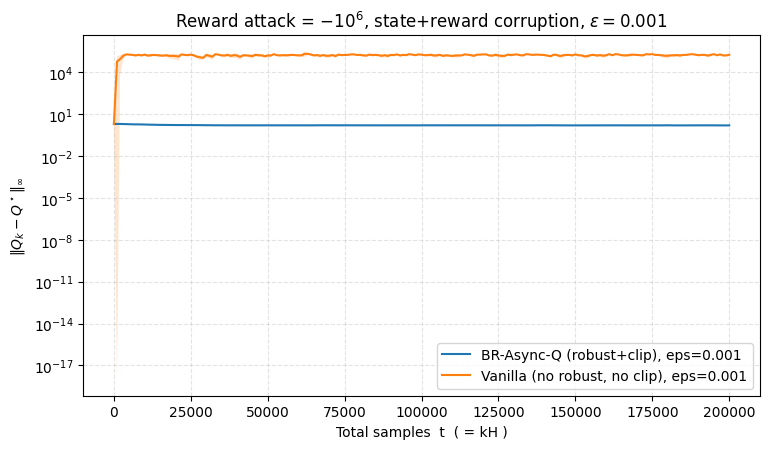

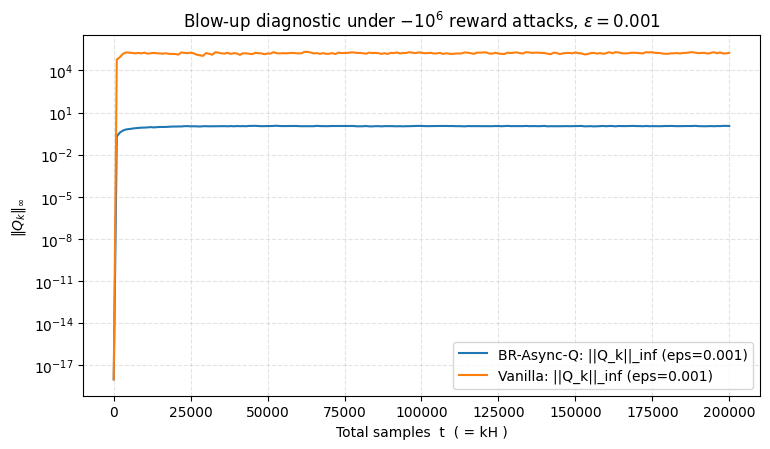

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List, Sequence, Tuple, Iterator, Optional

# ============================================================
# 1) Random MDP + Value Iteration to compute Q*
# ============================================================

def mdpgen(S: int, A: int, seed: int = 0):
    rng = np.random.default_rng(seed)

    P = rng.random((S, S, A))
    for a in range(A):
        P[:, :, a] /= P[:, :, a].sum(axis=1, keepdims=True)

    R = rng.random((S, A))  # rewards in [0,1)
    return P, R


def value_iteration(P: np.ndarray, R: np.ndarray, gamma: float,
                    max_iter: int = 200_000, tol: float = 1e-12):
    S, _, A = P.shape
    Q = np.zeros((S, A))
    residuals = []

    for _ in range(max_iter):
        Q_old = Q
        V = Q_old.max(axis=1)
        Q = R + gamma * np.tensordot(P, V, axes=([1], [0]))  # (S,A)
        res = np.max(np.abs(Q - Q_old))
        residuals.append(res)
        if res < tol:
            break

    return Q, np.array(residuals)


# ============================================================
# 2) Data stream with (i) reward corruption and (ii) state corruption
#    Reward attack: set reward to -1e6 (your request)
#    State attack: corrupt observed sampled state s_t and observed next-state s_{t+1}
# ============================================================

Transition = Tuple[int, int, float, int]

def mdp_stream_corrupted(
    P: np.ndarray,
    R: np.ndarray,
    T: int,
    seed: int,
    eps_R: float,
    eps_Y: float,
    attack_reward: float = -1_000_000.0,
) -> Iterator[Transition]:
    rng = np.random.default_rng(seed)
    S, _, A = P.shape

    s_true = int(rng.integers(S))
    for _ in range(T):
        a = int(rng.integers(A))

        # true transition + clean reward
        s_next_true = int(rng.choice(S, p=P[s_true, :, a]))
        r_true = float(R[s_true, a])

        # observed (possibly corrupted)
        s_obs = s_true
        s_next_obs = s_next_true
        r_obs = r_true

        # reward corruption
        if rng.random() < eps_R:
            r_obs = float(attack_reward)

        # state corruption (corrupt the observed sampled state and observed next state)
        if rng.random() < eps_Y:
            s_obs = int(rng.integers(S))
            s_next_obs = int(rng.integers(S))

        yield (s_obs, a, r_obs, s_next_obs)

        # advance true state
        s_true = s_next_true


# ============================================================
# 3) Robust TRIM (MoM center + trimming)
# ============================================================

def _median_of_means_center(x: np.ndarray, delta: float) -> float:
    n = x.size
    B = int(math.ceil(8.0 * math.log(2.0 / delta)))
    B = max(1, min(B, n))
    blocks = np.array_split(x, B)
    means = np.array([b.mean() for b in blocks if b.size > 0], dtype=float)
    return float(np.median(means))


def TRIM(samples: Sequence[float], eps: float, delta: float) -> float:
    x = np.asarray(samples, dtype=float)
    n = x.size
    if n == 0:
        raise ValueError("TRIM: empty sample.")
    m = int(math.ceil(eps * n))
    m = min(m, n - 1)  # keep at least one point

    if m == 0:
        return float(x.mean())

    c = _median_of_means_center(x, delta)
    order = np.argsort(np.abs(x - c))
    keep = order[: (n - m)]
    return float(x[keep].mean())


def clip(x: np.ndarray, lo: float, hi: float) -> np.ndarray:
    return np.minimum(np.maximum(x, lo), hi)


# ============================================================
# 4) BR-Async-Q (robust + clipping) and Vanilla (no robust, no clipping)
#    Both track:
#      err[k] = ||Q_k - Q*||_inf
#      qnorm[k] = ||Q_k||_inf  (to show blow-up)
# ============================================================

@dataclass
class Config:
    S: int
    A: int
    alpha: float
    gamma: float
    H: int
    K: int
    eps_Y: float
    eps_R: float
    delta_Y: float = 0.05
    delta_R: float = 0.05
    G: float = 1.0  # only used by robust version (clipping)


def br_async_q_with_metrics(cfg: Config, data: Iterator[Transition], Qstar: np.ndarray):
    S, A = cfg.S, cfg.A
    Q = np.zeros((S, A))

    err = np.zeros(cfg.K + 1)
    qnorm = np.zeros(cfg.K + 1)
    err[0] = np.max(np.abs(Q - Qstar))
    qnorm[0] = np.max(np.abs(Q))

    for k in range(cfg.K):
        R_lists: List[List[List[float]]] = [[[] for _ in range(A)] for __ in range(S)]
        Y_lists: List[List[List[float]]] = [[[] for _ in range(A)] for __ in range(S)]

        for _ in range(cfg.H):
            s, a, r, s_next = next(data)
            R_lists[s][a].append(float(r))
            Y_lists[s][a].append(float(np.max(Q[s_next, :])))

        mu_hat = np.zeros((S, A))
        R_hat = np.zeros((S, A))
        for s in range(S):
            for a in range(A):
                Ys = Y_lists[s][a]
                Rs = R_lists[s][a]
                mu_hat[s, a] = TRIM(Ys, cfg.eps_Y, cfg.delta_Y) if len(Ys) else float(np.max(Q[s, :]))
                R_hat[s, a]  = TRIM(Rs, cfg.eps_R, cfg.delta_R) if len(Rs) else 0.0

        # robust target with reward clipping
        T_hat = clip(R_hat, -cfg.G, cfg.G) + cfg.gamma * mu_hat
        Q = (1.0 - cfg.alpha) * Q + cfg.alpha * T_hat

        err[k + 1] = np.max(np.abs(Q - Qstar))
        qnorm[k + 1] = np.max(np.abs(Q))

    return Q, err, qnorm


def vanilla_epoch_q_with_metrics_NO_robust_NO_clip(cfg: Config, data: Iterator[Transition], Qstar: np.ndarray):
    """
    TRUE vanilla:
      - plain mean (no TRIM)
      - NO clipping/thresholding at all
    """
    S, A = cfg.S, cfg.A
    Q = np.zeros((S, A))

    err = np.zeros(cfg.K + 1)
    qnorm = np.zeros(cfg.K + 1)
    err[0] = np.max(np.abs(Q - Qstar))
    qnorm[0] = np.max(np.abs(Q))

    for k in range(cfg.K):
        R_lists: List[List[List[float]]] = [[[] for _ in range(A)] for __ in range(S)]
        Y_lists: List[List[List[float]]] = [[[] for _ in range(A)] for __ in range(S)]

        for _ in range(cfg.H):
            s, a, r, s_next = next(data)
            R_lists[s][a].append(float(r))
            Y_lists[s][a].append(float(np.max(Q[s_next, :])))

        mu_hat = np.zeros((S, A))
        R_hat = np.zeros((S, A))
        for s in range(S):
            for a in range(A):
                Ys = Y_lists[s][a]
                Rs = R_lists[s][a]
                mu_hat[s, a] = float(np.mean(Ys)) if len(Ys) else float(np.max(Q[s, :]))
                R_hat[s, a]  = float(np.mean(Rs)) if len(Rs) else 0.0

        # NO clipping here
        T_hat = R_hat + cfg.gamma * mu_hat
        Q = (1.0 - cfg.alpha) * Q + cfg.alpha * T_hat

        err[k + 1] = np.max(np.abs(Q - Qstar))
        qnorm[k + 1] = np.max(np.abs(Q))

        # optional: stop early if it clearly blows up (keeps runtime sane)
        if not np.isfinite(qnorm[k + 1]) or qnorm[k + 1] > 1e300:
            err[k + 1 :] = np.inf
            qnorm[k + 1 :] = np.inf
            break

    return Q, err, qnorm


# ============================================================
# 5) Helper for plotting blow-ups (replace inf/nan with big cap)
# ============================================================

def sanitize(y: np.ndarray, cap: float = 1e12) -> np.ndarray:
    y2 = y.astype(float).copy()
    bad = ~np.isfinite(y2)
    y2[bad] = cap
    y2 = np.clip(y2, 1e-18, cap)
    return y2


# ============================================================
# 6) Run epsilon sweep and plot: show blow-up of vanilla
# ============================================================

# MDP / algorithm parameters
S, A = 100, 40
gamma = 0.5

H, K = 1000, 200
T = H * K

alpha = 0.2
G_robust = 1.0                 # clipping keeps robust method bounded under -1e6 attacks
attack_reward = -1_000_000.0   # your corruption bias

eps_list = [0.001, 0.005, 0.01]
n_runs = 5

# generate MDP and compute clean Q*
P, R = mdpgen(S, A, seed=0)
Qstar, _ = value_iteration(P, R, gamma, max_iter=250_000, tol=1e-12)

x_epochs = np.arange(K + 1)
x_samples = x_epochs * H

for eps in eps_list:
    cfg = Config(S=S, A=A, alpha=alpha, gamma=gamma, H=H, K=K, eps_Y=eps, eps_R=eps, G=G_robust)

    br_errs, br_qnorms = [], []
    van_errs, van_qnorms = [], []

    for run in range(n_runs):
        stream_br = mdp_stream_corrupted(P, R, T, seed=100 + run, eps_R=eps, eps_Y=eps, attack_reward=attack_reward)
        _, e_br, q_br = br_async_q_with_metrics(cfg, iter(stream_br), Qstar)
        br_errs.append(e_br); br_qnorms.append(q_br)

        stream_v = mdp_stream_corrupted(P, R, T, seed=200 + run, eps_R=eps, eps_Y=eps, attack_reward=attack_reward)
        _, e_v, q_v = vanilla_epoch_q_with_metrics_NO_robust_NO_clip(cfg, iter(stream_v), Qstar)
        van_errs.append(e_v); van_qnorms.append(q_v)

    br_errs = np.vstack(br_errs)
    van_errs = np.vstack(van_errs)
    br_qnorms = np.vstack(br_qnorms)
    van_qnorms = np.vstack(van_qnorms)

    # mean/std (sanitized so inf doesn't wreck the plot)
    mean_br_err = sanitize(br_errs, cap=1e12).mean(axis=0)
    std_br_err  = sanitize(br_errs, cap=1e12).std(axis=0)

    mean_v_err  = sanitize(van_errs, cap=1e12).mean(axis=0)
    std_v_err   = sanitize(van_errs, cap=1e12).std(axis=0)

    mean_br_q   = sanitize(br_qnorms, cap=1e12).mean(axis=0)
    mean_v_q    = sanitize(van_qnorms, cap=1e12).mean(axis=0)

    print(f"\n=== eps={eps} ===")
    print(f"Robust final ||Q||_inf (mean over runs): {mean_br_q[-1]:.3e}")
    print(f"Vanilla final ||Q||_inf (mean over runs): {mean_v_q[-1]:.3e}   <-- blow-up expected")

    # Plot 1: error ||Q_k - Q*||_inf
    plt.figure(figsize=(7.8, 4.6))
    plt.plot(x_samples, mean_br_err, label=f"BR-Async-Q (robust+clip), eps={eps}")
    plt.fill_between(x_samples,
                     np.maximum(mean_br_err - std_br_err, 1e-18),
                     mean_br_err + std_br_err,
                     alpha=0.2)

    plt.plot(x_samples, mean_v_err, label=f"Vanilla (no robust, no clip), eps={eps}")
    plt.fill_between(x_samples,
                     np.maximum(mean_v_err - std_v_err, 1e-18),
                     mean_v_err + std_v_err,
                     alpha=0.2)

    plt.yscale("log")
    plt.xlabel("Total samples  t  ( = kH )")
    plt.ylabel(r"$\|Q_k - Q^\star\|_\infty$")
    plt.title(rf"Reward attack = $-10^6$, state+reward corruption, $\varepsilon={eps}$")
    plt.grid(True, which="both", linestyle="--", alpha=0.35)
    plt.legend()
    plt.tight_layout()
    plt.show()





=== eps=0.001 ===
Robust final ||Q||_inf (mean over runs): 1.104e+00
Vanilla final ||Q||_inf (mean over runs): 1.805e+05   <-- blow-up expected

=== eps=0.005 ===
Robust final ||Q||_inf (mean over runs): 1.130e+00
Vanilla final ||Q||_inf (mean over runs): 2.000e+05   <-- blow-up expected

=== eps=0.01 ===
Robust final ||Q||_inf (mean over runs): 1.084e+00
Vanilla final ||Q||_inf (mean over runs): 2.106e+05   <-- blow-up expected


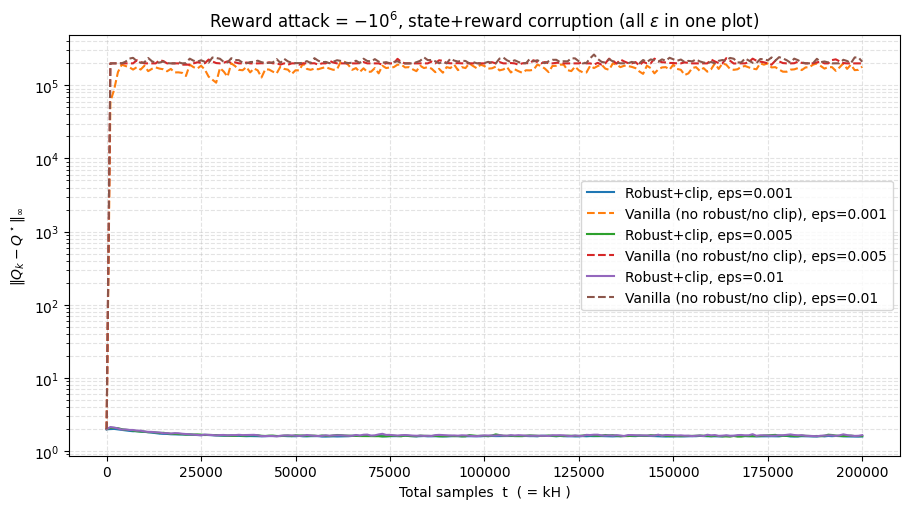

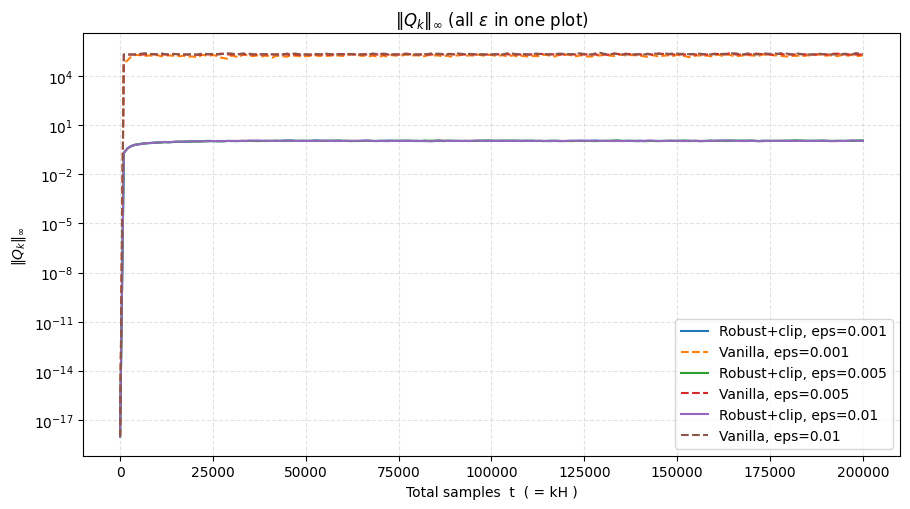


Saved sweep data to: eps_sweep_results.npz


In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List, Sequence, Tuple, Iterator

# ============================================================
# 1) Random MDP + Value Iteration to compute Q*
# ============================================================

def mdpgen(S: int, A: int, seed: int = 0):
    rng = np.random.default_rng(seed)

    P = rng.random((S, S, A))
    for a in range(A):
        P[:, :, a] /= P[:, :, a].sum(axis=1, keepdims=True)

    R = rng.random((S, A))  # rewards in [0,1)
    return P, R


def value_iteration(P: np.ndarray, R: np.ndarray, gamma: float,
                    max_iter: int = 200_000, tol: float = 1e-12):
    S, _, A = P.shape
    Q = np.zeros((S, A))
    residuals = []

    for _ in range(max_iter):
        Q_old = Q
        V = Q_old.max(axis=1)
        Q = R + gamma * np.tensordot(P, V, axes=([1], [0]))  # (S,A)
        res = np.max(np.abs(Q - Q_old))
        residuals.append(res)
        if res < tol:
            break

    return Q, np.array(residuals)


# ============================================================
# 2) Data stream with reward corruption + state corruption
# ============================================================

Transition = Tuple[int, int, float, int]

def mdp_stream_corrupted(
    P: np.ndarray,
    R: np.ndarray,
    T: int,
    seed: int,
    eps_R: float,
    eps_Y: float,
    attack_reward: float = -1_000_000.0,
) -> Iterator[Transition]:
    rng = np.random.default_rng(seed)
    S, _, A = P.shape

    s_true = int(rng.integers(S))
    for _ in range(T):
        a = int(rng.integers(A))

        # true transition + clean reward
        s_next_true = int(rng.choice(S, p=P[s_true, :, a]))
        r_true = float(R[s_true, a])

        # observed (possibly corrupted)
        s_obs = s_true
        s_next_obs = s_next_true
        r_obs = r_true

        # reward corruption
        if rng.random() < eps_R:
            r_obs = float(attack_reward)

        # state corruption (corrupt observed sampled state and observed next state)
        if rng.random() < eps_Y:
            s_obs = int(rng.integers(S))
            s_next_obs = int(rng.integers(S))

        yield (s_obs, a, r_obs, s_next_obs)

        # advance true state
        s_true = s_next_true


# ============================================================
# 3) Robust TRIM (MoM center + trimming)
# ============================================================

def _median_of_means_center(x: np.ndarray, delta: float) -> float:
    n = x.size
    B = int(math.ceil(8.0 * math.log(2.0 / delta)))
    B = max(1, min(B, n))
    blocks = np.array_split(x, B)
    means = np.array([b.mean() for b in blocks if b.size > 0], dtype=float)
    return float(np.median(means))


def TRIM(samples: Sequence[float], eps: float, delta: float) -> float:
    x = np.asarray(samples, dtype=float)
    n = x.size
    if n == 0:
        raise ValueError("TRIM: empty sample.")

    m = int(math.ceil(eps * n))
    m = min(m, n - 1)  # keep at least one point

    if m == 0:
        return float(x.mean())

    c = _median_of_means_center(x, delta)
    order = np.argsort(np.abs(x - c))
    keep = order[: (n - m)]
    return float(x[keep].mean())


def clip(x: np.ndarray, lo: float, hi: float) -> np.ndarray:
    return np.minimum(np.maximum(x, lo), hi)


# ============================================================
# 4) Robust BR-Async-Q (robust + clipping) and Vanilla (no robust, no clipping)
# ============================================================

@dataclass
class Config:
    S: int
    A: int
    alpha: float
    gamma: float
    H: int
    K: int
    eps_Y: float
    eps_R: float
    delta_Y: float = 0.05
    delta_R: float = 0.05
    G: float = 1.0  # only used by robust version (clipping)


def br_async_q_with_metrics(cfg: Config, data: Iterator[Transition], Qstar: np.ndarray):
    S, A = cfg.S, cfg.A
    Q = np.zeros((S, A))

    err = np.zeros(cfg.K + 1)
    qnorm = np.zeros(cfg.K + 1)
    err[0] = np.max(np.abs(Q - Qstar))
    qnorm[0] = np.max(np.abs(Q))

    for k in range(cfg.K):
        R_lists: List[List[List[float]]] = [[[] for _ in range(A)] for __ in range(S)]
        Y_lists: List[List[List[float]]] = [[[] for _ in range(A)] for __ in range(S)]

        for _ in range(cfg.H):
            s, a, r, s_next = next(data)
            R_lists[s][a].append(float(r))
            Y_lists[s][a].append(float(np.max(Q[s_next, :])))

        mu_hat = np.zeros((S, A))
        R_hat = np.zeros((S, A))
        for s in range(S):
            for a in range(A):
                Ys = Y_lists[s][a]
                Rs = R_lists[s][a]
                mu_hat[s, a] = TRIM(Ys, cfg.eps_Y, cfg.delta_Y) if len(Ys) else float(np.max(Q[s, :]))
                R_hat[s, a]  = TRIM(Rs, cfg.eps_R, cfg.delta_R) if len(Rs) else 0.0

        # robust target with reward clipping
        T_hat = clip(R_hat, -cfg.G, cfg.G) + cfg.gamma * mu_hat
        Q = (1.0 - cfg.alpha) * Q + cfg.alpha * T_hat

        err[k + 1] = np.max(np.abs(Q - Qstar))
        qnorm[k + 1] = np.max(np.abs(Q))

    return Q, err, qnorm


def vanilla_epoch_q_with_metrics_NO_robust_NO_clip(cfg: Config, data: Iterator[Transition], Qstar: np.ndarray):
    """
    TRUE vanilla:
      - plain mean (no TRIM)
      - NO clipping/thresholding at all
    """
    S, A = cfg.S, cfg.A
    Q = np.zeros((S, A))

    err = np.zeros(cfg.K + 1)
    qnorm = np.zeros(cfg.K + 1)
    err[0] = np.max(np.abs(Q - Qstar))
    qnorm[0] = np.max(np.abs(Q))

    for k in range(cfg.K):
        R_lists: List[List[List[float]]] = [[[] for _ in range(A)] for __ in range(S)]
        Y_lists: List[List[List[float]]] = [[[] for _ in range(A)] for __ in range(S)]

        for _ in range(cfg.H):
            s, a, r, s_next = next(data)
            R_lists[s][a].append(float(r))
            Y_lists[s][a].append(float(np.max(Q[s_next, :])))

        mu_hat = np.zeros((S, A))
        R_hat = np.zeros((S, A))
        for s in range(S):
            for a in range(A):
                Ys = Y_lists[s][a]
                Rs = R_lists[s][a]
                mu_hat[s, a] = float(np.mean(Ys)) if len(Ys) else float(np.max(Q[s, :]))
                R_hat[s, a]  = float(np.mean(Rs)) if len(Rs) else 0.0

        # NO clipping here
        T_hat = R_hat + cfg.gamma * mu_hat
        Q = (1.0 - cfg.alpha) * Q + cfg.alpha * T_hat

        err[k + 1] = np.max(np.abs(Q - Qstar))
        qnorm[k + 1] = np.max(np.abs(Q))

        # optional: stop early if it clearly blows up (keeps runtime sane)
        if (not np.isfinite(qnorm[k + 1])) or (qnorm[k + 1] > 1e300):
            err[k + 1:] = np.inf
            qnorm[k + 1:] = np.inf
            break

    return Q, err, qnorm


# ============================================================
# 5) Helper for plotting blow-ups (replace inf/nan with big cap)
# ============================================================

def sanitize(y: np.ndarray, cap: float = 1e12) -> np.ndarray:
    y2 = np.asarray(y, dtype=float).copy()
    bad = ~np.isfinite(y2)
    y2[bad] = cap
    y2 = np.clip(y2, 1e-18, cap)  # keep positive for log scale
    return y2


# ============================================================
# 6) Run epsilon sweep, plot ALL eps in ONE figure, and SAVE data
# ============================================================

def main():
    # MDP / algorithm parameters
    S, A = 100, 40
    gamma = 0.5

    H, K = 1000, 200
    T = H * K

    alpha = 0.2
    G_robust = 1.0                 # clipping keeps robust method bounded under -1e6 attacks
    attack_reward = -1_000_000.0   # corruption value

    eps_list = [0.001, 0.005, 0.01]
    n_runs = 5

    # generate MDP and compute clean Q*
    P, R = mdpgen(S, A, seed=0)
    Qstar, _ = value_iteration(P, R, gamma, max_iter=250_000, tol=1e-12)

    x_epochs = np.arange(K + 1)
    x_samples = x_epochs * H

    # Allocate storage (raw + stats)
    E = len(eps_list)

    br_errs_raw    = np.zeros((E, n_runs, K + 1), dtype=float)
    van_errs_raw   = np.zeros((E, n_runs, K + 1), dtype=float)
    br_qnorms_raw  = np.zeros((E, n_runs, K + 1), dtype=float)
    van_qnorms_raw = np.zeros((E, n_runs, K + 1), dtype=float)

    seeds_br = np.array([100 + r for r in range(n_runs)], dtype=int)
    seeds_v  = np.array([200 + r for r in range(n_runs)], dtype=int)

    # Run sweep
    for i, eps in enumerate(eps_list):
        cfg = Config(S=S, A=A, alpha=alpha, gamma=gamma, H=H, K=K,
                     eps_Y=eps, eps_R=eps, G=G_robust)

        for run in range(n_runs):
            stream_br = mdp_stream_corrupted(
                P, R, T, seed=int(seeds_br[run]), eps_R=eps, eps_Y=eps, attack_reward=attack_reward
            )
            _, e_br, q_br = br_async_q_with_metrics(cfg, iter(stream_br), Qstar)
            br_errs_raw[i, run, :]   = e_br
            br_qnorms_raw[i, run, :] = q_br

            stream_v = mdp_stream_corrupted(
                P, R, T, seed=int(seeds_v[run]), eps_R=eps, eps_Y=eps, attack_reward=attack_reward
            )
            _, e_v, q_v = vanilla_epoch_q_with_metrics_NO_robust_NO_clip(cfg, iter(stream_v), Qstar)
            van_errs_raw[i, run, :]   = e_v
            van_qnorms_raw[i, run, :] = q_v

    # Compute mean/std (sanitized for plotting/log-scale)
    cap = 1e12

    br_errs_s  = sanitize(br_errs_raw,  cap=cap)
    van_errs_s = sanitize(van_errs_raw, cap=cap)

    br_q_s  = sanitize(br_qnorms_raw,  cap=cap)
    van_q_s = sanitize(van_qnorms_raw, cap=cap)

    mean_br_err = br_errs_s.mean(axis=1)     # (E, K+1)
    std_br_err  = br_errs_s.std(axis=1)

    mean_v_err  = van_errs_s.mean(axis=1)
    std_v_err   = van_errs_s.std(axis=1)

    mean_br_q   = br_q_s.mean(axis=1)
    mean_v_q    = van_q_s.mean(axis=1)

    # Print summaries
    for i, eps in enumerate(eps_list):
        print(f"\n=== eps={eps} ===")
        print(f"Robust final ||Q||_inf (mean over runs): {mean_br_q[i, -1]:.3e}")
        print(f"Vanilla final ||Q||_inf (mean over runs): {mean_v_q[i, -1]:.3e}   <-- blow-up expected")

    # Plot ALL eps in ONE figure (error curves)
    plt.figure(figsize=(9.2, 5.2))
    for i, eps in enumerate(eps_list):
        plt.plot(x_samples, mean_br_err[i], linestyle="-",  label=f"Robust+clip, eps={eps:g}")
        plt.plot(x_samples, mean_v_err[i],  linestyle="--", label=f"Vanilla (no robust/no clip), eps={eps:g}")

        # If you want shading, uncomment (can get visually busy):
        # plt.fill_between(
        #     x_samples,
        #     np.maximum(mean_br_err[i] - std_br_err[i], 1e-18),
        #     mean_br_err[i] + std_br_err[i],
        #     alpha=0.12
        # )
        # plt.fill_between(
        #     x_samples,
        #     np.maximum(mean_v_err[i] - std_v_err[i], 1e-18),
        #     mean_v_err[i] + std_v_err[i],
        #     alpha=0.12
        # )

    plt.yscale("log")
    plt.xlabel("Total samples  t  ( = kH )")
    plt.ylabel(r"$\|Q_k - Q^\star\|_\infty$")
    plt.title(r"Reward attack = $-10^6$, state+reward corruption (all $\varepsilon$ in one plot)")
    plt.grid(True, which="both", linestyle="--", alpha=0.35)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # SAVE everything (raw + stats + MDP + Q*)
    save_path = "eps_sweep_results.npz"
    np.savez_compressed(
        save_path,
        # metadata / params
        eps_list=np.array(eps_list, dtype=float),
        n_runs=int(n_runs),
        S=int(S), A=int(A), gamma=float(gamma), alpha=float(alpha),
        H=int(H), K=int(K), T=int(T),
        G_robust=float(G_robust),
        attack_reward=float(attack_reward),
        seeds_br=seeds_br,
        seeds_v=seeds_v,

        # axes
        x_epochs=x_epochs,
        x_samples=x_samples,

        # MDP + Q*
        P=P,
        R=R,
        Qstar=Qstar,

        # raw runs
        br_errs_raw=br_errs_raw,
        van_errs_raw=van_errs_raw,
        br_qnorms_raw=br_qnorms_raw,
        van_qnorms_raw=van_qnorms_raw,

        # summary stats (sanitized for plotting)
        mean_br_err=mean_br_err,
        std_br_err=std_br_err,
        mean_v_err=mean_v_err,
        std_v_err=std_v_err,
        mean_br_q=mean_br_q,
        mean_v_q=mean_v_q,
    )
    print(f"\nSaved sweep data to: {save_path}")


if __name__ == "__main__":
    main()


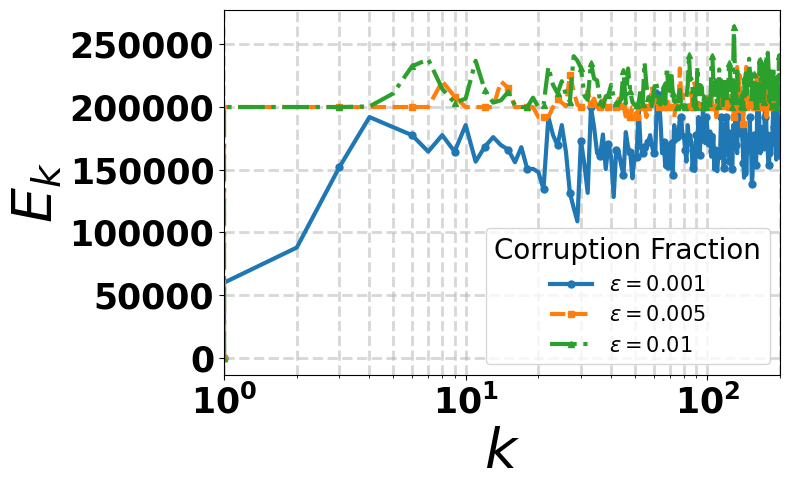

Saved: Vanilla_Q_error_envelope_per_eps.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# --- Your saved runs (.npz files) ---
paths = [
    "eps_sweep_results.npz",
    # add more npz files here if you want an envelope across multiple experiments
]

# Which curve do you want to plot?
# Options saved by my code:
#   "mean_v_err", "mean_br_err", "mean_v_q", "mean_br_q"
KEY = "mean_v_err"   # vanilla Q-error curve (mean over runs inside each file)

# ----------------------------
# Load arrays from all files
# ----------------------------
arrays = []
x = None
epsilons = None

for p in paths:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Could not find file: {p}")

    data = np.load(p)

    if KEY not in data:
        raise KeyError(f"{p} does not contain '{KEY}'. Available keys: {list(data.keys())}")

    arr = data[KEY]  # shape: (num_eps, T_len) where T_len = K+1
    arrays.append(arr)

    # get common x-axis + eps list from the first file
    if x is None:
        if "x_epochs" in data:
            x = data["x_epochs"]  # (T_len,)
        else:
            x = np.arange(arr.shape[1])

        if "eps_list" in data:
            epsilons = data["eps_list"]  # (num_eps,)
        else:
            epsilons = np.arange(arr.shape[0])

    data.close()

# ----------------------------
# Truncate to common horizon
# ----------------------------
T_min = min(a.shape[1] for a in arrays)
arrays = [a[:, :T_min] for a in arrays]
x = x[:T_min]

# semilogx needs strictly positive x
x_plot = x.astype(float).copy()
if x_plot[0] <= 0:
    # replace the first point with the second (or 1 if length=1)
    x_plot[0] = x_plot[1] if T_min > 1 else 1.0
# also ensure nothing is <= 0
x_plot[x_plot <= 0] = 1.0

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(8, 5))

linestyles = ['-', '--', '-.']
markers    = ['o', 's', '^']

for eps_idx, eps in enumerate(epsilons):
    # stack this epsilon curve across files: shape (num_files, T_min)
    curves = np.stack([a[eps_idx] for a in arrays], axis=0)

    lower = np.min(curves, axis=0)
    upper = np.max(curves, axis=0)
    mean_curve = np.mean(curves, axis=0)

    # envelope
    plt.fill_between(
        x_plot,
        lower,
        upper,
        alpha=0.15,
        linewidth=0
    )

    # mean curve
    plt.semilogx(
        x_plot,
        mean_curve,
        linestyles[eps_idx % len(linestyles)],
        linewidth=3,
        marker=markers[eps_idx % len(markers)],
        markersize=5,
        markevery=max(1, T_min // 60),
        label=fr"$\epsilon={float(eps):g}$"
    )

# IMPORTANT: xlim lower bound must be positive for log-x
plt.xlim([x_plot[0], x_plot[-1]])

plt.xlabel(r'$\mathit{k}$', fontsize=40, fontweight='bold')
plt.ylabel(r'$\mathit{E_k}$', fontsize=40, fontweight='bold')

plt.legend(
    fontsize=15,
    title='Corruption Fraction',
    title_fontsize=20,
    loc='lower right'
)

plt.xticks(fontsize=25, fontweight='bold')
plt.yticks(fontsize=25, fontweight='bold')
plt.grid(True, which="both", linestyle="--", alpha=0.5, linewidth=2)
plt.tight_layout()

out = "Vanilla_Q_error_envelope_per_eps.png"
plt.savefig(out, dpi=1200, bbox_inches="tight")
plt.show()

print(f"Saved: {out}")


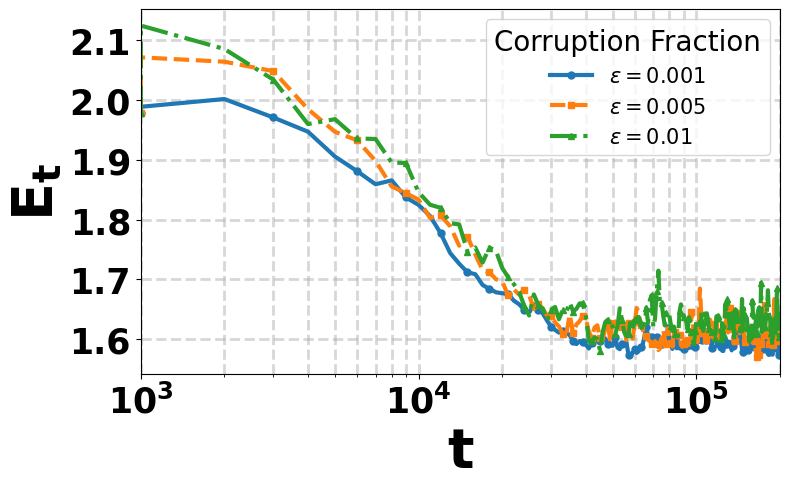

Saved: Vanilla_Q_error_envelope_per_eps.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# --- Your saved runs (.npz files) ---
paths = [
    "eps_sweep_results.npz",
    # add more npz files here if you want an envelope across multiple experiments
]

# Which curve do you want to plot?
# Options saved by my code:
#   "mean_v_err", "mean_br_err", "mean_v_q", "mean_br_q"
KEY = "mean_br_err"   # vanilla Q-error curve (mean over runs inside each file)

# ----------------------------
# Load arrays from all files
# ----------------------------
arrays = []
x = None
epsilons = None

for p in paths:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Could not find file: {p}")

    data = np.load(p)

    if KEY not in data:
        raise KeyError(f"{p} does not contain '{KEY}'. Available keys: {list(data.keys())}")

    arr = data[KEY]  # shape: (num_eps, T_len) where T_len = K+1
    arrays.append(arr)

    # get common x-axis + eps list from the first file
    if x is None:
        if "x_samples" in data:
            x = data["x_samples"]  # (T_len,)
        else:
            x = np.arange(arr.shape[1])

        if "eps_list" in data:
            epsilons = data["eps_list"]  # (num_eps,)
        else:
            epsilons = np.arange(arr.shape[0])

    data.close()

# ----------------------------
# Truncate to common horizon
# ----------------------------
T_min = min(a.shape[1] for a in arrays)
arrays = [a[:, :T_min] for a in arrays]
x = x[:T_min]

# semilogx needs strictly positive x
x_plot = x.astype(float).copy()
if x_plot[0] <= 0:
    # replace the first point with the second (or 1 if length=1)
    x_plot[0] = x_plot[1] if T_min > 1 else 1.0
# also ensure nothing is <= 0
x_plot[x_plot <= 0] = 1.0

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(8, 5))

linestyles = ['-', '--', '-.']
markers    = ['o', 's', '^']

for eps_idx, eps in enumerate(epsilons):
    # stack this epsilon curve across files: shape (num_files, T_min)
    curves = np.stack([a[eps_idx] for a in arrays], axis=0)

    lower = np.min(curves, axis=0)
    upper = np.max(curves, axis=0)
    mean_curve = np.mean(curves, axis=0)

    # envelope
    plt.fill_between(
        x_plot,
        lower,
        upper,
        alpha=0.15,
        linewidth=0
    )

    # mean curve
    plt.semilogx(
        x_plot,
        mean_curve,
        linestyles[eps_idx % len(linestyles)],
        linewidth=3,
        marker=markers[eps_idx % len(markers)],
        markersize=5,
        markevery=max(1, T_min // 60),
        label=fr"$\epsilon={float(eps):g}$"
    )

# IMPORTANT: xlim lower bound must be positive for log-x
plt.xlim([x_plot[0], x_plot[-1]])

plt.xlabel(r'$\mathbf{t}$', fontsize=40, fontweight='bold')
plt.ylabel(r'$\mathbf{E_t}$', fontsize=40, fontweight='bold')

plt.legend(
    fontsize=15,
    title='Corruption Fraction',
    title_fontsize=20,
    loc='upper right'
)

plt.xticks(fontsize=25, fontweight='bold')
plt.yticks(fontsize=25, fontweight='bold')
plt.grid(True, which="both", linestyle="--", alpha=0.5, linewidth=2)
plt.tight_layout()

out = "Vanilla_Q_error_envelope_per_eps.png"
plt.savefig(out, dpi=1200, bbox_inches="tight")
plt.show()

print(f"Saved: {out}")


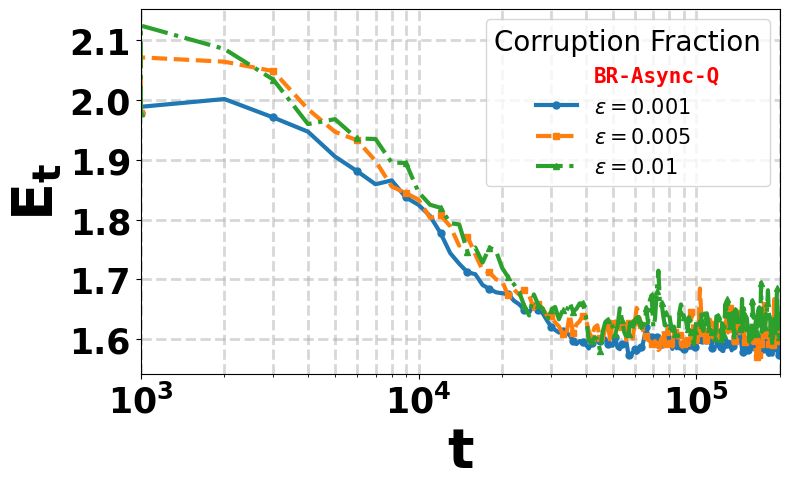

Saved: Vanilla_Q_error_envelope_per_eps.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# --- Your saved runs (.npz files) ---
paths = [
    "eps_sweep_results.npz",
    # add more npz files here if you want an envelope across multiple experiments
]

# Which curve do you want to plot?
# Options saved by my code:
#   "mean_v_err", "mean_br_err", "mean_v_q", "mean_br_q"
KEY = "mean_br_err"   # robust Q-error curve (mean over runs inside each file)

# ----------------------------
# Load arrays from all files
# ----------------------------
arrays = []
x = None
epsilons = None

for p in paths:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Could not find file: {p}")

    data = np.load(p)

    if KEY not in data:
        raise KeyError(f"{p} does not contain '{KEY}'. Available keys: {list(data.keys())}")

    arr = data[KEY]  # shape: (num_eps, T_len) where T_len = K+1
    arrays.append(arr)

    # get common x-axis + eps list from the first file
    if x is None:
        if "x_samples" in data:
            x = data["x_samples"]  # (T_len,)
        else:
            x = np.arange(arr.shape[1])

        if "eps_list" in data:
            epsilons = data["eps_list"]  # (num_eps,)
        else:
            epsilons = np.arange(arr.shape[0])

    data.close()

# ----------------------------
# Truncate to common horizon
# ----------------------------
T_min = min(a.shape[1] for a in arrays)
arrays = [a[:, :T_min] for a in arrays]
x = x[:T_min]

# semilogx needs strictly positive x
x_plot = x.astype(float).copy()
if x_plot[0] <= 0:
    x_plot[0] = x_plot[1] if T_min > 1 else 1.0
x_plot[x_plot <= 0] = 1.0

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(8, 5))

linestyles = ['-', '--', '-.']
markers    = ['o', 's', '^']

for eps_idx, eps in enumerate(epsilons):
    # stack this epsilon curve across files: shape (num_files, T_min)
    curves = np.stack([a[eps_idx] for a in arrays], axis=0)

    lower = np.min(curves, axis=0)
    upper = np.max(curves, axis=0)
    mean_curve = np.mean(curves, axis=0)

    # envelope
    plt.fill_between(
        x_plot,
        lower,
        upper,
        alpha=0.15,
        linewidth=0
    )

    # mean curve
    plt.semilogx(
        x_plot,
        mean_curve,
        linestyles[eps_idx % len(linestyles)],
        linewidth=3,
        marker=markers[eps_idx % len(markers)],
        markersize=5,
        markevery=max(1, T_min // 60),
        label=fr"$\epsilon={float(eps):g}$"
    )

# IMPORTANT: xlim lower bound must be positive for log-x
plt.xlim([x_plot[0], x_plot[-1]])

plt.xlabel(r'$\mathbf{t}$', fontsize=40, fontweight='bold')
plt.ylabel(r'$\mathbf{E_t}$', fontsize=40, fontweight='bold')

# ----------------------------
# Legend: add BR-Async-Q at top INSIDE legend box
# ----------------------------
dummy = plt.Line2D([], [], linestyle='None', marker=None)  # invisible handle for text row
handles, labels = plt.gca().get_legend_handles_labels()

handles = [dummy] + handles
labels  = ["BR-Async-Q"] + labels

leg = plt.legend(
    handles=handles,
    labels=labels,
    fontsize=15,
    title='Corruption Fraction',
    title_fontsize=20,
    loc='upper right'
)

# style the first legend row ("BR-Async-Q")
leg_texts = leg.get_texts()
leg_texts[0].set_color("red")
leg_texts[0].set_fontfamily("monospace")  # mimics \texttt
leg_texts[0].set_fontweight("bold")
# ----------------------------

plt.xticks(fontsize=25, fontweight='bold')
plt.yticks(fontsize=25, fontweight='bold')
plt.grid(True, which="both", linestyle="--", alpha=0.5, linewidth=2)
plt.tight_layout()

out = "Vanilla_Q_error_envelope_per_eps.png"
plt.savefig(out, dpi=1200, bbox_inches="tight")
plt.show()

print(f"Saved: {out}")


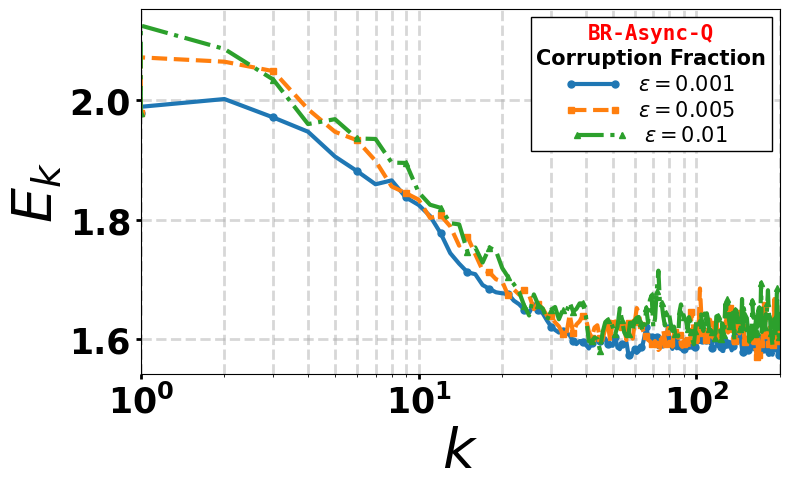

Saved: Vanilla_Q_error_envelope_per_eps.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

from matplotlib.offsetbox import AnchoredOffsetbox, VPacker, HPacker, TextArea, DrawingArea
import matplotlib.lines as mlines

# --- Your saved runs (.npz files) ---
paths = [
    "eps_sweep_results.npz",
    # add more npz files here if you want an envelope across multiple experiments
]

# Which curve do you want to plot?
# Options saved by my code:
#   "mean_v_err", "mean_br_err", "mean_v_q", "mean_br_q"
KEY = "mean_br_err"   # robust Q-error curve (mean over runs inside each file)

# ----------------------------
# Load arrays from all files
# ----------------------------
arrays = []
x = None
epsilons = None

for p in paths:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Could not find file: {p}")

    data = np.load(p)

    if KEY not in data:
        raise KeyError(f"{p} does not contain '{KEY}'. Available keys: {list(data.keys())}")

    arr = data[KEY]  # shape: (num_eps, T_len) where T_len = K+1
    arrays.append(arr)

    # get common x-axis + eps list from the first file
    if x is None:
        if "x_epochs" in data:
            x = data["x_epochs"]  # (T_len,)
        else:
            x = np.arange(arr.shape[1])

        if "eps_list" in data:
            epsilons = data["eps_list"]  # (num_eps,)
        else:
            epsilons = np.arange(arr.shape[0])

    data.close()

# ----------------------------
# Truncate to common horizon
# ----------------------------
T_min = min(a.shape[1] for a in arrays)
arrays = [a[:, :T_min] for a in arrays]
x = x[:T_min]

# semilogx needs strictly positive x
x_plot = x.astype(float).copy()
if x_plot[0] <= 0:
    x_plot[0] = x_plot[1] if T_min > 1 else 1.0
x_plot[x_plot <= 0] = 1.0

# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots(figsize=(8, 5))

linestyles = ['-', '--', '-.']
markers    = ['o', 's', '^']

for eps_idx, eps in enumerate(epsilons):
    # stack this epsilon curve across files: shape (num_files, T_min)
    curves = np.stack([a[eps_idx] for a in arrays], axis=0)

    lower = np.min(curves, axis=0)
    upper = np.max(curves, axis=0)
    mean_curve = np.mean(curves, axis=0)

    # envelope
    ax.fill_between(
        x_plot,
        lower,
        upper,
        alpha=0.15,
        linewidth=0
    )

    # mean curve
    ax.semilogx(
        x_plot,
        mean_curve,
        linestyles[eps_idx % len(linestyles)],
        linewidth=3,
        marker=markers[eps_idx % len(markers)],
        markersize=5,
        markevery=max(1, T_min // 60),
        label=fr"$\epsilon={float(eps):g}$"
    )

# IMPORTANT: xlim lower bound must be positive for log-x
ax.set_xlim([x_plot[0], x_plot[-1]])

ax.set_xlabel(r'$\mathit{k}$', fontsize=40, fontweight='bold')
ax.set_ylabel(r'$\mathit{E_k}$', fontsize=40, fontweight='bold')

ax.tick_params(axis='both', labelsize=25, width=2)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

ax.grid(True, which="both", linestyle="--", alpha=0.5, linewidth=2)

# ============================================================
# Custom legend box (fully aligned & centered INSIDE plot)
#   BR-Async-Q            (red, monospace)
#   Corruption Fraction   (bold)
#   [line sample]  eps=...
# ============================================================

handles, labels = ax.get_legend_handles_labels()

# Header lines (centered)
header1 = TextArea(
    "BR-Async-Q",
    textprops=dict(color="red", family="monospace", weight="bold", size=15, ha="center")
)
header2 = TextArea(
    "Corruption Fraction",
    textprops=dict(color="black", weight="bold", size=15, ha="center")
)

rows = []
for h, lab in zip(handles, labels):
    # build a mini handle that matches the plotted line style
    da = DrawingArea(44, 14, 0, 0)

    line = mlines.Line2D(
        [2, 34], [7, 7],
        linestyle=h.get_linestyle(),
        linewidth=h.get_linewidth(),
        color=h.get_color(),
        marker=h.get_marker(),
        markersize=h.get_markersize(),
        markerfacecolor=h.get_markerfacecolor(),
        markeredgecolor=h.get_markeredgecolor(),
    )
    da.add_artist(line)

    txt = TextArea(lab, textprops=dict(size=15, ha="left"))
    row = HPacker(children=[da, txt], align="center", pad=0, sep=6)
    rows.append(row)

# Stack everything, center-aligned
legend_vbox = VPacker(children=[header1, header2] + rows, align="center", pad=0, sep=4)

anch = AnchoredOffsetbox(
    loc="upper right",
    child=legend_vbox,
    frameon=True,
    borderpad=0.6
)
ax.add_artist(anch)

# optional: tweak legend box appearance
anch.patch.set_alpha(1.0)

# ============================================================

plt.tight_layout()

out = "Vanilla_Q_error_envelope_per_eps.png"
plt.savefig(out, dpi=1200, bbox_inches="tight")
plt.show()

print(f"Saved: {out}")


In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List, Sequence, Tuple, Iterator

# ============================================================
# 1) Random MDP + Value Iteration to compute Q*
# ============================================================

def mdpgen(S: int, A: int, seed: int = 0):
    rng = np.random.default_rng(seed)

    P = rng.random((S, S, A))
    for a in range(A):
        P[:, :, a] /= P[:, :, a].sum(axis=1, keepdims=True)

    R = rng.random((S, A))  # rewards in [0,1)
    return P, R


def value_iteration(P: np.ndarray, R: np.ndarray, gamma: float,
                    max_iter: int = 200_000, tol: float = 1e-12):
    S, _, A = P.shape
    Q = np.zeros((S, A))
    residuals = []

    for _ in range(max_iter):
        Q_old = Q
        V = Q_old.max(axis=1)
        Q = R + gamma * np.tensordot(P, V, axes=([1], [0]))  # (S,A)
        res = np.max(np.abs(Q - Q_old))
        residuals.append(res)
        if res < tol:
            break

    return Q, np.array(residuals)


# ============================================================
# 2) Data stream with reward corruption + state corruption
#    PLUS additive training noise on reward: N(0, noise_var)
# ============================================================

Transition = Tuple[int, int, float, int]

def mdp_stream_corrupted(
    P: np.ndarray,
    R: np.ndarray,
    T: int,
    seed: int,
    eps_R: float,
    eps_Y: float,
    attack_reward: float = -1_000_000.0,
    noise_var: float = 0.0,   # <-- NEW
) -> Iterator[Transition]:
    rng = np.random.default_rng(seed)
    S, _, A = P.shape

    noise_std = math.sqrt(noise_var) if noise_var > 0 else 0.0

    s_true = int(rng.integers(S))
    for _ in range(T):
        a = int(rng.integers(A))

        # true transition + clean reward
        s_next_true = int(rng.choice(S, p=P[s_true, :, a]))
        r_true = float(R[s_true, a])

        # observed (possibly corrupted)
        s_obs = s_true
        s_next_obs = s_next_true
        r_obs = r_true

        # reward corruption
        if rng.random() < eps_R:
            r_obs = float(attack_reward)

        # state corruption (corrupt observed sampled state and observed next state)
        if rng.random() < eps_Y:
            s_obs = int(rng.integers(S))
            s_next_obs = int(rng.integers(S))

        # additive training noise on observed reward (zero-mean Gaussian)
        if noise_std > 0:
            r_obs = float(r_obs + rng.normal(0.0, noise_std))

        yield (s_obs, a, r_obs, s_next_obs)

        # advance true state
        s_true = s_next_true


# ============================================================
# 3) Robust TRIM (MoM center + trimming)
# ============================================================

def _median_of_means_center(x: np.ndarray, delta: float) -> float:
    n = x.size
    B = int(math.ceil(8.0 * math.log(2.0 / delta)))
    B = max(1, min(B, n))
    blocks = np.array_split(x, B)
    means = np.array([b.mean() for b in blocks if b.size > 0], dtype=float)
    return float(np.median(means))


def TRIM(samples: Sequence[float], eps: float, delta: float) -> float:
    x = np.asarray(samples, dtype=float)
    n = x.size
    if n == 0:
        raise ValueError("TRIM: empty sample.")

    m = int(math.ceil(eps * n))
    m = min(m, n - 1)  # keep at least one point

    if m == 0:
        return float(x.mean())

    c = _median_of_means_center(x, delta)
    order = np.argsort(np.abs(x - c))
    keep = order[: (n - m)]
    return float(x[keep].mean())


def clip(x: np.ndarray, lo: float, hi: float) -> np.ndarray:
    return np.minimum(np.maximum(x, lo), hi)


# ============================================================
# 4) Robust BR-Async-Q (robust + clipping) and Vanilla (no robust, no clipping)
# ============================================================

@dataclass
class Config:
    S: int
    A: int
    alpha: float
    gamma: float
    H: int
    K: int
    eps_Y: float
    eps_R: float
    delta_Y: float = 0.05
    delta_R: float = 0.05
    G: float = 1.0  # only used by robust version (clipping)


def br_async_q_with_metrics(cfg: Config, data: Iterator[Transition], Qstar: np.ndarray):
    S, A = cfg.S, cfg.A
    Q = np.zeros((S, A))

    err = np.zeros(cfg.K + 1)
    qnorm = np.zeros(cfg.K + 1)
    err[0] = np.max(np.abs(Q - Qstar))
    qnorm[0] = np.max(np.abs(Q))

    for k in range(cfg.K):
        R_lists: List[List[List[float]]] = [[[] for _ in range(A)] for __ in range(S)]
        Y_lists: List[List[List[float]]] = [[[] for _ in range(A)] for __ in range(S)]

        for _ in range(cfg.H):
            s, a, r, s_next = next(data)
            R_lists[s][a].append(float(r))
            Y_lists[s][a].append(float(np.max(Q[s_next, :])))

        mu_hat = np.zeros((S, A))
        R_hat = np.zeros((S, A))
        for s in range(S):
            for a in range(A):
                Ys = Y_lists[s][a]
                Rs = R_lists[s][a]
                mu_hat[s, a] = TRIM(Ys, cfg.eps_Y, cfg.delta_Y) if len(Ys) else float(np.max(Q[s, :]))
                R_hat[s, a]  = TRIM(Rs, cfg.eps_R, cfg.delta_R) if len(Rs) else 0.0

        # robust target with reward clipping
        T_hat = clip(R_hat, -cfg.G, cfg.G) + cfg.gamma * mu_hat
        Q = (1.0 - cfg.alpha) * Q + cfg.alpha * T_hat

        err[k + 1] = np.max(np.abs(Q - Qstar))
        qnorm[k + 1] = np.max(np.abs(Q))

    return Q, err, qnorm


def vanilla_epoch_q_with_metrics_NO_robust_NO_clip(cfg: Config, data: Iterator[Transition], Qstar: np.ndarray):
    """
    TRUE vanilla:
      - plain mean (no TRIM)
      - NO clipping/thresholding at all
    """
    S, A = cfg.S, cfg.A
    Q = np.zeros((S, A))

    err = np.zeros(cfg.K + 1)
    qnorm = np.zeros(cfg.K + 1)
    err[0] = np.max(np.abs(Q - Qstar))
    qnorm[0] = np.max(np.abs(Q))

    for k in range(cfg.K):
        R_lists: List[List[List[float]]] = [[[] for _ in range(A)] for __ in range(S)]
        Y_lists: List[List[List[float]]] = [[[] for _ in range(A)] for __ in range(S)]

        for _ in range(cfg.H):
            s, a, r, s_next = next(data)
            R_lists[s][a].append(float(r))
            Y_lists[s][a].append(float(np.max(Q[s_next, :])))

        mu_hat = np.zeros((S, A))
        R_hat = np.zeros((S, A))
        for s in range(S):
            for a in range(A):
                Ys = Y_lists[s][a]
                Rs = R_lists[s][a]
                mu_hat[s, a] = float(np.mean(Ys)) if len(Ys) else float(np.max(Q[s, :]))
                R_hat[s, a]  = float(np.mean(Rs)) if len(Rs) else 0.0

        # NO clipping here
        T_hat = R_hat + cfg.gamma * mu_hat
        Q = (1.0 - cfg.alpha) * Q + cfg.alpha * T_hat

        err[k + 1] = np.max(np.abs(Q - Qstar))
        qnorm[k + 1] = np.max(np.abs(Q))

        if (not np.isfinite(qnorm[k + 1])) or (qnorm[k + 1] > 1e300):
            err[k + 1:] = np.inf
            qnorm[k + 1:] = np.inf
            break

    return Q, err, qnorm


# ============================================================
# 5) Helper for plotting blow-ups (replace inf/nan with big cap)
# ============================================================

def sanitize(y: np.ndarray, cap: float = 1e12) -> np.ndarray:
    y2 = np.asarray(y, dtype=float).copy()
    bad = ~np.isfinite(y2)
    y2[bad] = cap
    y2 = np.clip(y2, 1e-18, cap)  # keep positive for log scale
    return y2


# ============================================================
# 6) Fix epsilon=0.01, sweep reward-noise variance in {2,5,10}, save npz
# ============================================================

def main():
    # MDP / algorithm parameters
    S, A = 100, 40
    gamma = 0.5

    H, K = 1000, 200
    T = H * K

    alpha = 0.2
    G_robust = 1.0
    attack_reward = -1_000_000.0

    # FIX corruption
    eps = 0.01  # <-- fixed epsilon

    # VARY training noise variance
    var_list = [2.0, 5.0, 10.0]  # Gaussian reward noise variance (mean 0)
    V = len(var_list)

    n_runs = 5

    # generate MDP and compute clean Q*
    P, R = mdpgen(S, A, seed=0)
    Qstar, _ = value_iteration(P, R, gamma, max_iter=250_000, tol=1e-12)

    x_epochs = np.arange(K + 1)
    x_samples = x_epochs * H

    # Allocate storage
    br_errs_raw    = np.zeros((V, n_runs, K + 1), dtype=float)
    van_errs_raw   = np.zeros((V, n_runs, K + 1), dtype=float)
    br_qnorms_raw  = np.zeros((V, n_runs, K + 1), dtype=float)
    van_qnorms_raw = np.zeros((V, n_runs, K + 1), dtype=float)

    # deterministic per-(var,run) seeds
    base_br = 10_000
    base_v  = 20_000

    cfg = Config(S=S, A=A, alpha=alpha, gamma=gamma, H=H, K=K,
                 eps_Y=eps, eps_R=eps, G=G_robust)

    for vi, var in enumerate(var_list):
        for run in range(n_runs):
            seed_br = base_br + 1000 * vi + run
            seed_v  = base_v  + 1000 * vi + run

            stream_br = mdp_stream_corrupted(
                P, R, T,
                seed=seed_br,
                eps_R=eps, eps_Y=eps,
                attack_reward=attack_reward,
                noise_var=var
            )
            _, e_br, q_br = br_async_q_with_metrics(cfg, iter(stream_br), Qstar)
            br_errs_raw[vi, run, :]   = e_br
            br_qnorms_raw[vi, run, :] = q_br

            stream_v = mdp_stream_corrupted(
                P, R, T,
                seed=seed_v,
                eps_R=eps, eps_Y=eps,
                attack_reward=attack_reward,
                noise_var=var
            )
            _, e_v, q_v = vanilla_epoch_q_with_metrics_NO_robust_NO_clip(cfg, iter(stream_v), Qstar)
            van_errs_raw[vi, run, :]   = e_v
            van_qnorms_raw[vi, run, :] = q_v

    # Stats (sanitized)
    cap = 1e12
    br_errs_s  = sanitize(br_errs_raw,  cap=cap)
    van_errs_s = sanitize(van_errs_raw, cap=cap)
    br_q_s     = sanitize(br_qnorms_raw,  cap=cap)
    van_q_s    = sanitize(van_qnorms_raw, cap=cap)

    mean_br_err = br_errs_s.mean(axis=1)   # (V, K+1)
    std_br_err  = br_errs_s.std(axis=1)
    mean_v_err  = van_errs_s.mean(axis=1)
    std_v_err   = van_errs_s.std(axis=1)

    mean_br_q   = br_q_s.mean(axis=1)
    mean_v_q    = van_q_s.mean(axis=1)

    for vi, var in enumerate(var_list):
        print(f"\n=== eps={eps} | noise_var={var} ===")
        print(f"Robust final ||Q||_inf (mean):  {mean_br_q[vi, -1]:.3e}")
        print(f"Vanilla final ||Q||_inf (mean): {mean_v_q[vi, -1]:.3e}")

    # Save file
    save_path = "var_sweep_eps0p01.npz"
    np.savez_compressed(
        save_path,
        eps=float(eps),
        var_list=np.array(var_list, dtype=float),
        n_runs=int(n_runs),

        S=int(S), A=int(A),
        gamma=float(gamma), alpha=float(alpha),
        H=int(H), K=int(K), T=int(T),
        G_robust=float(G_robust),
        attack_reward=float(attack_reward),

        x_epochs=x_epochs,
        x_samples=x_samples,

        P=P,
        R=R,
        Qstar=Qstar,

        br_errs_raw=br_errs_raw,
        van_errs_raw=van_errs_raw,
        br_qnorms_raw=br_qnorms_raw,
        van_qnorms_raw=van_qnorms_raw,

        mean_br_err=mean_br_err,
        std_br_err=std_br_err,
        mean_v_err=mean_v_err,
        std_v_err=std_v_err,
        mean_br_q=mean_br_q,
        mean_v_q=mean_v_q,
    )
    print(f"\nSaved variance sweep data to: {save_path}")




if __name__ == "__main__":
    main()



=== eps=0.01 | noise_var=2.0 ===
Robust final ||Q||_inf (mean):  9.721e-01
Vanilla final ||Q||_inf (mean): 2.079e+05

=== eps=0.01 | noise_var=5.0 ===
Robust final ||Q||_inf (mean):  9.794e-01
Vanilla final ||Q||_inf (mean): 2.079e+05

=== eps=0.01 | noise_var=10.0 ===
Robust final ||Q||_inf (mean):  9.428e-01
Vanilla final ||Q||_inf (mean): 2.163e+05

Saved variance sweep data to: var_sweep_eps0p01.npz


<>:126: SyntaxWarning: invalid escape sequence '\e'
<>:126: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_943/682036008.py:126: SyntaxWarning: invalid escape sequence '\e'
  "BR-Async-Q with $\epsilon = 0.2$",


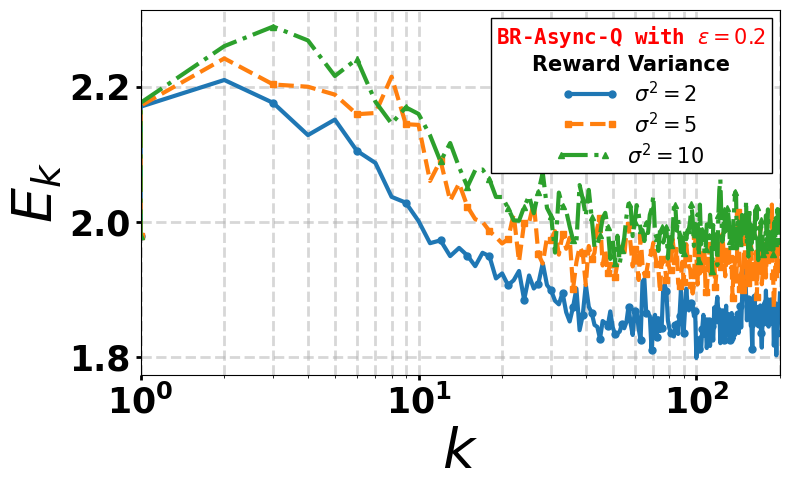

Saved: BR_Q_error_envelope_per_sigma2.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

from matplotlib.offsetbox import AnchoredOffsetbox, VPacker, HPacker, TextArea, DrawingArea
import matplotlib.lines as mlines

# --- Your saved runs (.npz files) ---
paths = [
    "var_sweep_eps0p01.npz",
    # add more npz files here if you want an envelope across multiple experiments
]

# Which curve do you want to plot?
# Options saved by my code:
#   "mean_v_err", "mean_br_err", "mean_v_q", "mean_br_q"
KEY = "mean_br_err"   # robust Q-error curve (mean over runs inside each file)

# ----------------------------
# Load arrays from all files
# ----------------------------
arrays = []
x = None
sig2_list = None  # <-- NEW (sigma^2 values)

for p in paths:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Could not find file: {p}")

    data = np.load(p)

    if KEY not in data:
        raise KeyError(f"{p} does not contain '{KEY}'. Available keys: {list(data.keys())}")

    arr = data[KEY]  # shape: (num_sig2, T_len) where T_len = K+1
    arrays.append(arr)

    # get common x-axis + sigma^2 list from the first file
    if x is None:
        if "x_epochs" in data:
            x = data["x_epochs"]  # (T_len,)
        else:
            x = np.arange(arr.shape[1])

        # In var_sweep_eps0p01.npz we saved "var_list"
        if "var_list" in data:
            sig2_list = data["var_list"]  # (num_sig2,)
        else:
            sig2_list = np.arange(arr.shape[0])

    data.close()

# ----------------------------
# Truncate to common horizon
# ----------------------------
T_min = min(a.shape[1] for a in arrays)
arrays = [a[:, :T_min] for a in arrays]
x = x[:T_min]

# semilogx needs strictly positive x
x_plot = x.astype(float).copy()
if x_plot[0] <= 0:
    x_plot[0] = x_plot[1] if T_min > 1 else 1.0
x_plot[x_plot <= 0] = 1.0

# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots(figsize=(8, 5))

linestyles = ['-', '--', '-.']
markers    = ['o', 's', '^']

for idx, sig2 in enumerate(sig2_list):
    # stack this sigma^2 curve across files: shape (num_files, T_min)
    curves = np.stack([a[idx] for a in arrays], axis=0)

    lower = np.min(curves, axis=0)
    upper = np.max(curves, axis=0)
    mean_curve = np.mean(curves, axis=0)

    # envelope
    ax.fill_between(
        x_plot,
        lower,
        upper,
        alpha=0.15,
        linewidth=0
    )

    # mean curve
    ax.semilogx(
        x_plot,
        mean_curve,
        linestyles[idx % len(linestyles)],
        linewidth=3,
        marker=markers[idx % len(markers)],
        markersize=5,
        markevery=max(1, T_min // 60),
        label=rf"$\sigma^2={float(sig2):g}$"
    )

# IMPORTANT: xlim lower bound must be positive for log-x
ax.set_xlim([x_plot[0], x_plot[-1]])

ax.set_xlabel(r'$\mathit{k}$', fontsize=40, fontweight='bold')
ax.set_ylabel(r'$\mathit{E_k}$', fontsize=40, fontweight='bold')

ax.tick_params(axis='both', labelsize=25, width=2)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

ax.grid(True, which="both", linestyle="--", alpha=0.5, linewidth=2)

# ============================================================
# Custom legend box (fully aligned & centered INSIDE plot)
#   BR-Async-Q            (red, monospace)
#   sigma^2               (bold)
#   [line sample]  sigma^2=...
# ============================================================

handles, labels = ax.get_legend_handles_labels()

# Header lines (centered)
header1 = TextArea(
    "BR-Async-Q with $\epsilon = 0.2$",
    textprops=dict(color="red", family="monospace", weight="bold", size=15, ha="center")
)
header2 = TextArea(
    "Reward Variance",
    textprops=dict(color="black", weight="bold", size=15, ha="center")
)

rows = []
for h, lab in zip(handles, labels):
    da = DrawingArea(44, 14, 0, 0)

    line = mlines.Line2D(
        [2, 34], [7, 7],
        linestyle=h.get_linestyle(),
        linewidth=h.get_linewidth(),
        color=h.get_color(),
        marker=h.get_marker(),
        markersize=h.get_markersize(),
        markerfacecolor=h.get_markerfacecolor(),
        markeredgecolor=h.get_markeredgecolor(),
    )
    da.add_artist(line)

    txt = TextArea(lab, textprops=dict(size=15, ha="left"))
    row = HPacker(children=[da, txt], align="center", pad=0, sep=6)
    rows.append(row)

legend_vbox = VPacker(children=[header1, header2] + rows, align="center", pad=0, sep=4)

anch = AnchoredOffsetbox(
    loc="upper right",
    child=legend_vbox,
    frameon=True,
    borderpad=0.6
)
ax.add_artist(anch)
anch.patch.set_alpha(1.0)

# ============================================================

plt.tight_layout()

out = "BR_Q_error_envelope_per_sigma2.png"
plt.savefig(out, dpi=1200, bbox_inches="tight")
plt.show()

print(f"Saved: {out}")


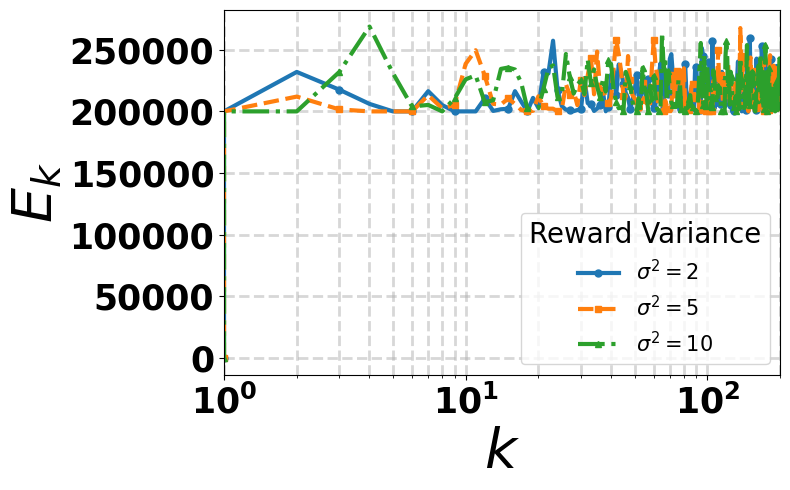

Saved: Vanilla_Q_error_envelope_per_sigma2.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# --- Your saved runs (.npz files) ---
paths = [
    "var_sweep_eps0p01.npz",
    # add more npz files here if you want an envelope across multiple experiments
]

# Vanilla Q-error curve (mean over runs inside each file)
KEY = "mean_v_err"

# ----------------------------
# Load arrays from all files
# ----------------------------
arrays = []
x = None
var_list = None

for p in paths:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Could not find file: {p}")

    data = np.load(p)

    if KEY not in data:
        raise KeyError(f"{p} does not contain '{KEY}'. Available keys: {list(data.keys())}")

    arr = data[KEY]          # shape: (num_vars, T_len)
    arrays.append(arr)

    if x is None:
        x = data["x_epochs"] if "x_epochs" in data else np.arange(arr.shape[1])
        var_list = data["var_list"] if "var_list" in data else np.arange(arr.shape[0])

    data.close()

# ----------------------------
# Truncate to common horizon
# ----------------------------
T_min = min(a.shape[1] for a in arrays)
arrays = [a[:, :T_min] for a in arrays]
x = x[:T_min]

# semilogx needs strictly positive x
x_plot = x.astype(float).copy()
if x_plot[0] <= 0:
    x_plot[0] = x_plot[1] if T_min > 1 else 1.0
x_plot[x_plot <= 0] = 1.0

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(8, 5))

linestyles = ['-', '--', '-.']
markers    = ['o', 's', '^']

for i, var in enumerate(var_list):
    # stack this variance curve across files: shape (num_files, T_min)
    curves = np.stack([a[i] for a in arrays], axis=0)

    lower = np.min(curves, axis=0)
    upper = np.max(curves, axis=0)
    mean_curve = np.mean(curves, axis=0)

    plt.fill_between(x_plot, lower, upper, alpha=0.15, linewidth=0)

    plt.semilogx(
        x_plot,
        mean_curve,
        linestyles[i % len(linestyles)],
        linewidth=3,
        marker=markers[i % len(markers)],
        markersize=5,
        markevery=max(1, T_min // 60),
        label=rf"$\sigma^2={float(var):g}$"
    )

plt.xlim([x_plot[0], x_plot[-1]])

plt.xlabel(r'$\mathit{k}$', fontsize=40, fontweight='bold')
plt.ylabel(r'$\mathit{E_k}$', fontsize=40, fontweight='bold')

plt.legend(
    fontsize=15,
    title="Reward Variance",
    title_fontsize=20,
    loc='lower right'
)

plt.xticks(fontsize=25, fontweight='bold')
plt.yticks(fontsize=25, fontweight='bold')
plt.grid(True, which="both", linestyle="--", alpha=0.5, linewidth=2)
plt.tight_layout()

out = "Vanilla_Q_error_envelope_per_sigma2.png"
plt.savefig(out, dpi=1200, bbox_inches="tight")
plt.show()

print(f"Saved: {out}")


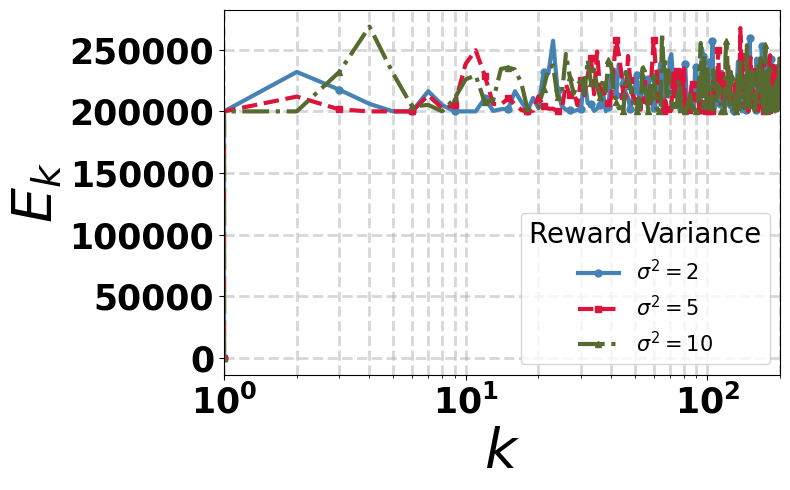

Saved: Vanilla_Q_error_envelope_per_sigma2.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# --- Your saved runs (.npz files) ---
paths = [
    "var_sweep_eps0p01.npz",
    # add more npz files here if you want an envelope across multiple experiments
]

# Vanilla Q-error curve (mean over runs inside each file)
KEY = "mean_v_err"

# ----------------------------
# Load arrays from all files
# ----------------------------
arrays = []
x = None
var_list = None

for p in paths:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Could not find file: {p}")

    data = np.load(p)

    if KEY not in data:
        raise KeyError(f"{p} does not contain '{KEY}'. Available keys: {list(data.keys())}")

    arr = data[KEY]          # shape: (num_vars, T_len)
    arrays.append(arr)

    if x is None:
        x = data["x_epochs"] if "x_epochs" in data else np.arange(arr.shape[1])
        var_list = data["var_list"] if "var_list" in data else np.arange(arr.shape[0])

    data.close()

# ----------------------------
# Truncate to common horizon
# ----------------------------
T_min = min(a.shape[1] for a in arrays)
arrays = [a[:, :T_min] for a in arrays]
x = x[:T_min]

# semilogx needs strictly positive x
x_plot = x.astype(float).copy()
if x_plot[0] <= 0:
    x_plot[0] = x_plot[1] if T_min > 1 else 1.0
x_plot[x_plot <= 0] = 1.0

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(8, 5))

linestyles = ['-', '--', '-.']
markers    = ['o', 's', '^']

# EXACT colors requested (one per variance curve)
colors = ["steelblue", "crimson", "darkolivegreen"]

for i, var in enumerate(var_list):
    # stack this variance curve across files: shape (num_files, T_min)
    curves = np.stack([a[i] for a in arrays], axis=0)

    lower = np.min(curves, axis=0)
    upper = np.max(curves, axis=0)
    mean_curve = np.mean(curves, axis=0)

    c = colors[i % len(colors)]

    # envelope (match curve color)
    plt.fill_between(x_plot, lower, upper, alpha=0.15, linewidth=0, color=c)

    # mean curve
    plt.semilogx(
        x_plot,
        mean_curve,
        linestyles[i % len(linestyles)],
        linewidth=3,
        marker=markers[i % len(markers)],
        markersize=5,
        markevery=max(1, T_min // 60),
        color=c,
        label=rf"$\sigma^2={float(var):g}$"
    )

plt.xlim([x_plot[0], x_plot[-1]])

plt.xlabel(r'$\mathit{k}$', fontsize=40, fontweight='bold')
plt.ylabel(r'$\mathit{E_k}$', fontsize=40, fontweight='bold')

plt.legend(
    fontsize=15,
    title="Reward Variance",
    title_fontsize=20,
    loc='lower right'
)

plt.xticks(fontsize=25, fontweight='bold')
plt.yticks(fontsize=25, fontweight='bold')
plt.grid(True, which="both", linestyle="--", alpha=0.5, linewidth=2)
plt.tight_layout()

out = "Vanilla_Q_error_envelope_per_sigma2.png"
plt.savefig(out, dpi=1200, bbox_inches="tight")
plt.show()

print(f"Saved: {out}")


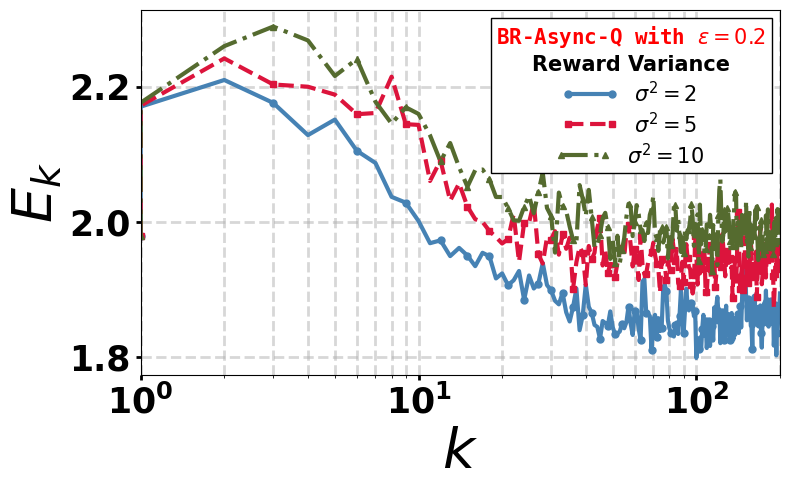

Saved: BR_Q_error_envelope_per_sigma2.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

from matplotlib.offsetbox import AnchoredOffsetbox, VPacker, HPacker, TextArea, DrawingArea
import matplotlib.lines as mlines

# --- Your saved runs (.npz files) ---
paths = [
    "var_sweep_eps0p01.npz",
    # add more npz files here if you want an envelope across multiple experiments
]

# Which curve do you want to plot?
# Options saved by my code:
#   "mean_v_err", "mean_br_err", "mean_v_q", "mean_br_q"
KEY = "mean_br_err"   # robust Q-error curve (mean over runs inside each file)

# ----------------------------
# Load arrays from all files
# ----------------------------
arrays = []
x = None
sig2_list = None  # sigma^2 values

for p in paths:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Could not find file: {p}")

    data = np.load(p)

    if KEY not in data:
        raise KeyError(f"{p} does not contain '{KEY}'. Available keys: {list(data.keys())}")

    arr = data[KEY]  # shape: (num_sig2, T_len)
    arrays.append(arr)

    if x is None:
        x = data["x_epochs"] if "x_epochs" in data else np.arange(arr.shape[1])
        sig2_list = data["var_list"] if "var_list" in data else np.arange(arr.shape[0])

    data.close()

# ----------------------------
# Truncate to common horizon
# ----------------------------
T_min = min(a.shape[1] for a in arrays)
arrays = [a[:, :T_min] for a in arrays]
x = x[:T_min]

# semilogx needs strictly positive x
x_plot = x.astype(float).copy()
if x_plot[0] <= 0:
    x_plot[0] = x_plot[1] if T_min > 1 else 1.0
x_plot[x_plot <= 0] = 1.0

# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots(figsize=(8, 5))

linestyles = ['-', '--', '-.']
markers    = ['o', 's', '^']

# EXACT colors requested (one per sigma^2 curve)
colors = ["steelblue", "crimson", "darkolivegreen"]

for idx, sig2 in enumerate(sig2_list):
    curves = np.stack([a[idx] for a in arrays], axis=0)

    lower = np.min(curves, axis=0)
    upper = np.max(curves, axis=0)
    mean_curve = np.mean(curves, axis=0)

    c = colors[idx % len(colors)]

    # envelope (match curve color)
    ax.fill_between(
        x_plot,
        lower,
        upper,
        alpha=0.15,
        linewidth=0,
        color=c
    )

    # mean curve (match curve color)
    ax.semilogx(
        x_plot,
        mean_curve,
        linestyles[idx % len(linestyles)],
        linewidth=3,
        marker=markers[idx % len(markers)],
        markersize=5,
        markevery=max(1, T_min // 60),
        color=c,
        label=rf"$\sigma^2={float(sig2):g}$"
    )

ax.set_xlim([x_plot[0], x_plot[-1]])

ax.set_xlabel(r'$\mathit{k}$', fontsize=40, fontweight='bold')
ax.set_ylabel(r'$\mathit{E_k}$', fontsize=40, fontweight='bold')

ax.tick_params(axis='both', labelsize=25, width=2)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

ax.grid(True, which="both", linestyle="--", alpha=0.5, linewidth=2)

# ============================================================
# Custom legend box (fully aligned & centered INSIDE plot)
# ============================================================

handles, labels = ax.get_legend_handles_labels()

header1 = TextArea(
    r"BR-Async-Q with $\epsilon = 0.2$",
    textprops=dict(color="red", family="monospace", weight="bold", size=15, ha="center")
)
header2 = TextArea(
    "Reward Variance",
    textprops=dict(color="black", weight="bold", size=15, ha="center")
)

rows = []
for h, lab in zip(handles, labels):
    da = DrawingArea(44, 14, 0, 0)

    line = mlines.Line2D(
        [2, 34], [7, 7],
        linestyle=h.get_linestyle(),
        linewidth=h.get_linewidth(),
        color=h.get_color(),
        marker=h.get_marker(),
        markersize=h.get_markersize(),
        markerfacecolor=h.get_markerfacecolor(),
        markeredgecolor=h.get_markeredgecolor(),
    )
    da.add_artist(line)

    txt = TextArea(lab, textprops=dict(size=15, ha="left"))
    row = HPacker(children=[da, txt], align="center", pad=0, sep=6)
    rows.append(row)

legend_vbox = VPacker(children=[header1, header2] + rows, align="center", pad=0, sep=4)

anch = AnchoredOffsetbox(
    loc="upper right",
    child=legend_vbox,
    frameon=True,
    borderpad=0.6
)
ax.add_artist(anch)
anch.patch.set_alpha(1.0)

# ============================================================

plt.tight_layout()

out = "BR_Q_error_envelope_per_sigma2.png"
plt.savefig(out, dpi=1200, bbox_inches="tight")
plt.show()

print(f"Saved: {out}")
